# **HR ATTRITION ANALYTICS**

Mengambil dan menampilkan struktur data

In [4]:
from google.colab import files

uploaded = files.upload()

Saving HR_data.xlsx to HR_data.xlsx


In [5]:
import pandas as pd
import io

file_name = list(uploaded.keys())[0]

# Baca file Excel ke dalam DataFrame pandas
df = pd.read_excel(io.BytesIO(uploaded[file_name]))

# 1. Menampilkan 5 baris pertama per kolom
print("Berikut 5 baris pertama data Anda:")
print(df.head())
print("\n" + "="*50 + "\n")

# 2. Menampilkan informasi
print("Informasi singkat tentang DataFrame:")
df.info()
print("\n" + "="*50 + "\n")

# 3. Menampilkan jumlah baris dan kolom
print(f"Jumlah baris (entri) dan kolom: {df.shape}")
print("\n" + "="*50 + "\n")

# 4. Menampilkan ringkasan statistik deskriptif untuk kolom numerik
print("Ringkasan statistik untuk kolom numerik:")
print(df.describe())

Berikut 5 baris pertama data Anda:
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction Standa

# **Data Cleaning**

In [6]:
import pandas as pd

# 1. Menghapus Kolom 'EmployeeCount' dan 'StandardHours' memiliki nilai yang sama di seluruh baris.
df = df.drop(columns=['EmployeeCount', 'StandardHours'])

# 2. Kolom tipe data kategorik ke numerik
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['OverTime'] = df['OverTime'].map({'Yes': 1, 'No': 0})

# 3. Tipe Data Kolom Kategori menjadi Teks
categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18']
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype('category')

# 4. Memeriksa dan Menghapus Duplikat
df = df.drop_duplicates(subset=['EmployeeNumber'], keep='first')

print("Informasi data setelah cleaning:")
df.info()

print("\nKolom Attrition setelah diubah:")
print(df['Attrition'].head())

Informasi data setelah cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Age                       1470 non-null   int64   
 1   Attrition                 1470 non-null   int64   
 2   BusinessTravel            1470 non-null   category
 3   DailyRate                 1470 non-null   int64   
 4   Department                1470 non-null   category
 5   DistanceFromHome          1470 non-null   int64   
 6   Education                 1470 non-null   int64   
 7   EducationField            1470 non-null   category
 8   EmployeeNumber            1470 non-null   int64   
 9   EnvironmentSatisfaction   1470 non-null   int64   
 10  Gender                    1470 non-null   category
 11  HourlyRate                1470 non-null   int64   
 12  JobInvolvement            1470 non-null   int64   
 13  JobLevel       

# **HR Data Analytics**

1. Persentase Berkurangnya karyawan berdasarkan **gender** dan **job role**
2. Persentase Attrition berdasarkan **Work Life Balance**
3. **Top 5 usia** dengan jumlah attrition tertinggi
4. **Top 3 Job role** dengan jumlah attrition terbanyak
5. **Top 3 Job role** dengan attrition paling sedikit
6. **Rata-rata gaji bulanan** per Job role
7. Persentase **performance** karyawan berdasarkan usia dan departemen
8. Persentase **lama bekerja karyawan** berdasarkan job role dan kepuasan bekerja
9. Perbandingan Jurusan kuliah karyawan dengan Job role
10. Perbandingan Attrition berdasarkan kelompok usia



In [7]:
# @title
import pandas as pd

print("1. Persentase Attrition berdasarkan Gender dan Job Role:")
attrition_by_gender_role = pd.crosstab(
    [df['JobRole'], df['Gender']],
    df['Attrition'],
    normalize='index'
).round(4) * 100
print(attrition_by_gender_role)
print("\n" + "="*80 + "\n")

print("2. Persentase Attrition berdasarkan Work Life Balance:")
attrition_by_wlb = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
).round(4) * 100
print(attrition_by_wlb)
print("\n" + "="*80 + "\n")

print("3. Top 5 Usia dengan Attrition Tertinggi:")
top_5_age_attrition = df.groupby('Age')['Attrition'].mean().sort_values(ascending=False).head(5).round(4) * 100
print(top_5_age_attrition)
print("\n" + "="*80 + "\n")

print("4. Top 3 Job Role dengan Attrition Terbanyak:")
top_3_job_role_attrition = df[df['Attrition'] == 1]['JobRole'].value_counts().head(3)
print(top_3_job_role_attrition)
print("\n" + "="*80 + "\n")

print("5. Top 3 Job Role dengan Attrition Paling Sedikit:")
least_3_job_role_attrition = df[df['Attrition'] == 1]['JobRole'].value_counts().tail(3)
print(least_3_job_role_attrition)
print("\n" + "="*80 + "\n")

print("6. Rata-rata Gaji Bulanan per Job Role:")
avg_monthly_income_by_role = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
print(avg_monthly_income_by_role)
print("\n" + "="*80 + "\n")

print("7. Persentase Performance Karyawan berdasarkan Usia dan Departemen:")
# membuat kolom kategori usia terlebih dahulu jika belum ada
performance_by_age_dept = pd.crosstab(
    [df['Department'], df['Age']],
    df['PerformanceRating'],
    normalize='index'
).round(4) * 100
print(performance_by_age_dept)
print("\n" + "="*80 + "\n")

print("8. Rata-rata Lama Bekerja berdasarkan Job Role dan Kepuasan Kerja:")
avg_years_by_role_satisfaction = df.groupby(['JobRole', 'JobSatisfaction'])['YearsAtCompany'].mean().unstack()
print(avg_years_by_role_satisfaction)
print("\n" + "="*80 + "\n")

print("9. Perbandingan Jurusan Kuliah dengan Job Role (Distribusi Karyawan):")
education_job_distribution = pd.crosstab(
    df['EducationField'],
    df['JobRole'],
    normalize='index'
).round(4) * 100
print(education_job_distribution)
print("\n" + "="*80 + "\n")

print("10. Perbandingan Attrition berdasarkan Kelompok Usia:")
df['AgeGroup'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60], labels=['20-29', '30-39', '40-49', '50-59'], right=False)

attrition_by_age_group = pd.crosstab(
    df['AgeGroup'],
    df['Attrition'],
    normalize='index'
).round(4) * 100
print(attrition_by_age_group)
print("\n" + "="*80 + "\n")

1. Persentase Attrition berdasarkan Gender dan Job Role:
Attrition                             0      1
JobRole                   Gender              
Healthcare Representative 0       90.20   9.80
                          1       95.00   5.00
Human Resources           0       62.50  37.50
                          1       83.33  16.67
Laboratory Technician     0       81.18  18.82
                          1       73.56  26.44
Manager                   0       95.74   4.26
                          1       94.55   5.45
Manufacturing Director    0       94.44   5.56
                          1       91.78   8.22
Research Director         0       96.97   3.03
                          1       97.87   2.13
Research Scientist        0       85.09  14.91
                          1       83.15  16.85
Sales Executive           0       84.85  15.15
                          1       80.93  19.07
Sales Representative      0       57.89  42.11
                          1       62.22  37.78


2

/tmp/ipython-input-3127111564.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_monthly_income_by_role = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
/tmp/ipython-input-3127111564.py:53: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_years_by_role_satisfaction = df.groupby(['JobRole', 'JobSatisfaction'])['YearsAtCompany'].mean().unstack()


# **Data Analytics with Graph**

1. Attrition % by Gender and Job Role → bar chart dengan warna berbeda untuk gender

2. Attrition % by Work Life Balance → bar chart

3. Attrition % by Age Group → bar chart per kelompok umur.

4. Top 3 Job Roles with Highest Attrition → horizontal bar chart.

5. Average Monthly Income per Job Role → horizontal bar chart

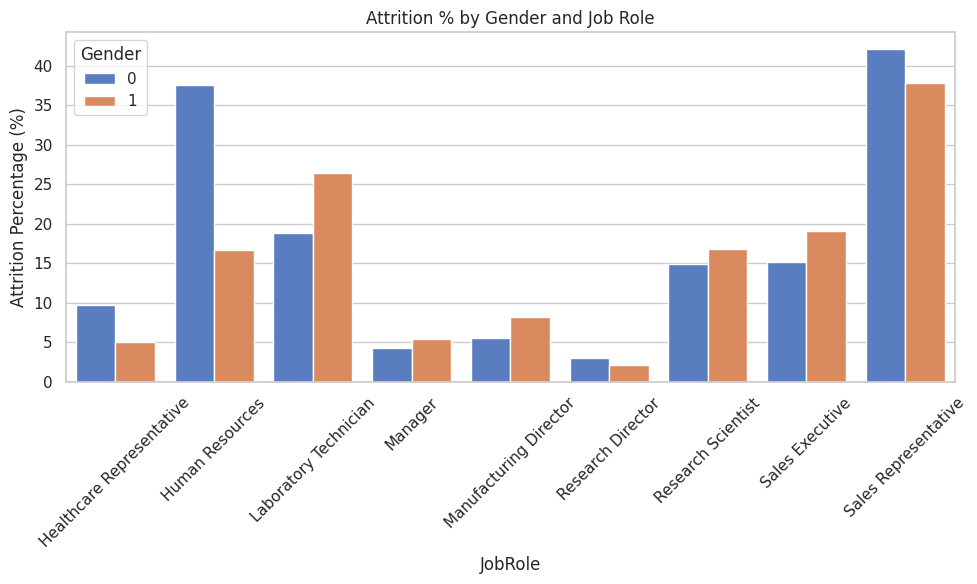

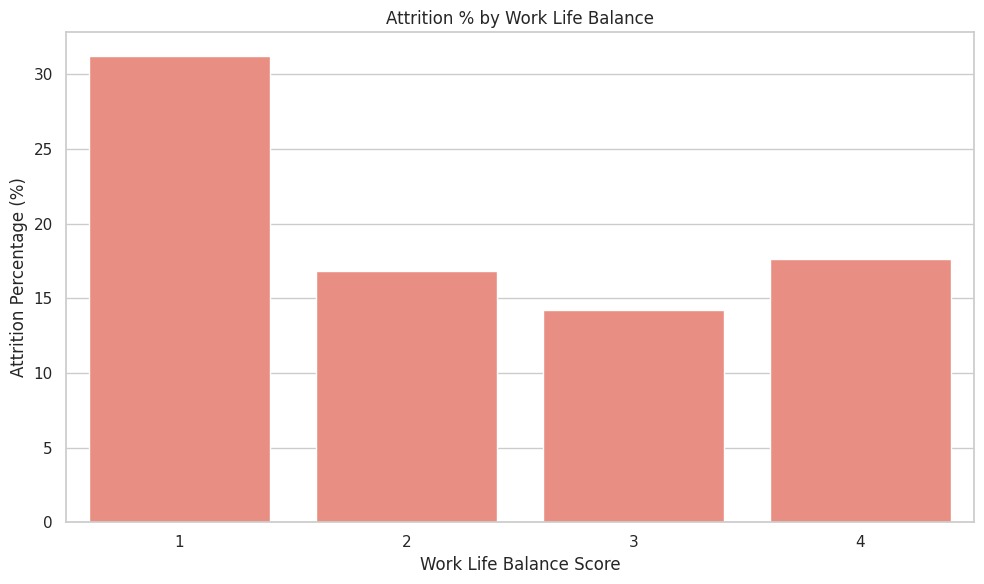

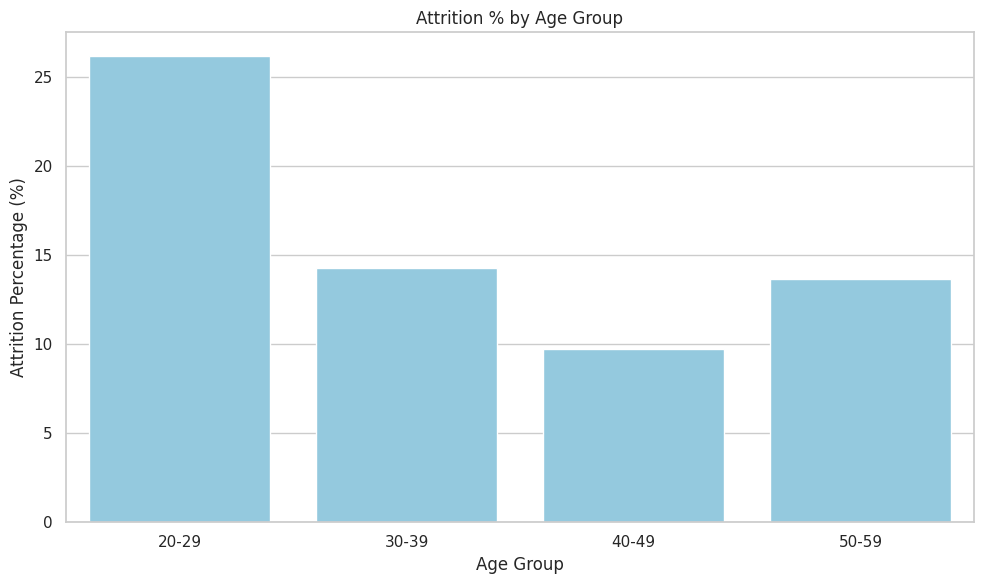

/tmp/ipython-input-351514324.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


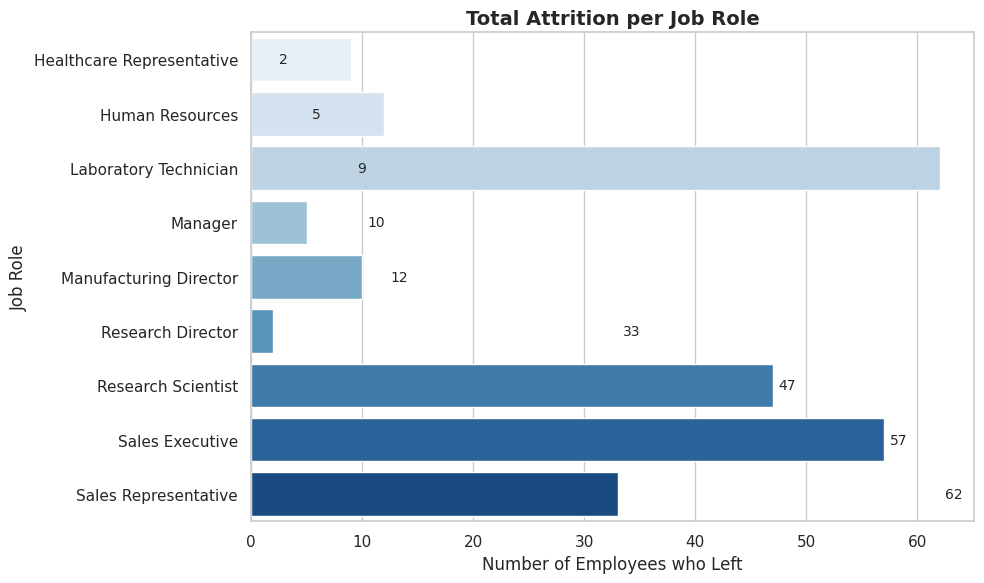

/tmp/ipython-input-351514324.py:106: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_monthly_income_by_role = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)
/tmp/ipython-input-351514324.py:108: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


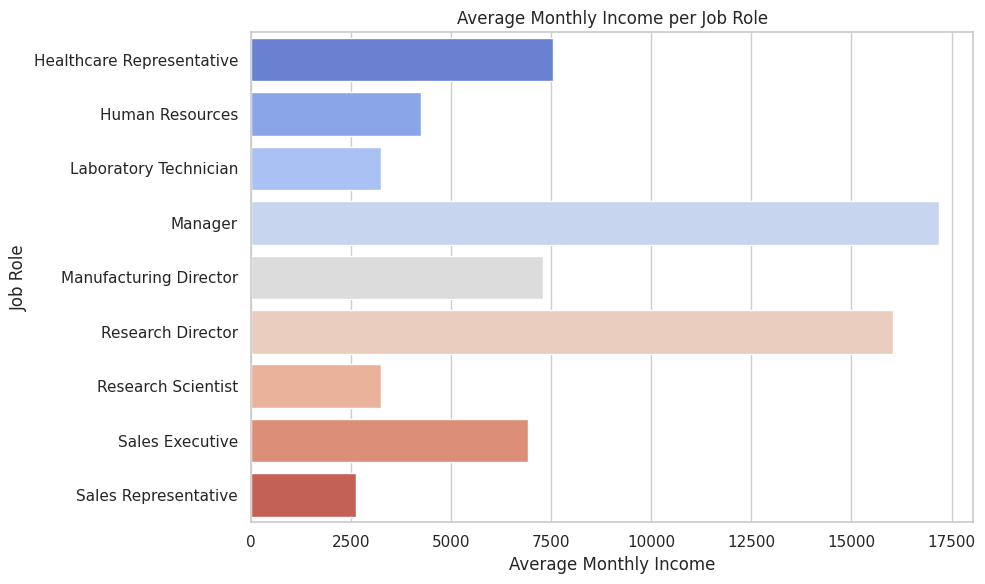

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10,6)

# 1. Attrition by Gender and Job Role
plt.figure()
attrition_by_gender_role = pd.crosstab(
    [df['JobRole'], df['Gender']],
    df['Attrition'],
    normalize='index'
).round(4) * 100

attrition_by_gender_role.columns = ['Attrition_0', 'Attrition_1']
attrition_by_gender_role.reset_index(inplace=True)

sns.barplot(
    data=attrition_by_gender_role,
    x="JobRole",
    y="Attrition_1",
    hue="Gender"
)
plt.title("Attrition % by Gender and Job Role")
plt.ylabel("Attrition Percentage (%)")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

# 2. Attrition by Work Life Balance
plt.figure()
attrition_by_wlb = pd.crosstab(
    df['WorkLifeBalance'],
    df['Attrition'],
    normalize='index'
).round(4) * 100

attrition_by_wlb.columns = ['Attrition_0','Attrition_1']
attrition_by_wlb.reset_index(inplace=True)

sns.barplot(
    data=attrition_by_wlb,
    x="WorkLifeBalance",
    y="Attrition_1",
    color="salmon"
)
plt.title("Attrition % by Work Life Balance")
plt.ylabel("Attrition Percentage (%)")
plt.xlabel("Work Life Balance Score")
plt.tight_layout()
plt.show()

# 3. Attrition by Age Group
plt.figure()
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[20, 30, 40, 50, 60],
    labels=['20-29', '30-39', '40-49', '50-59'],
    right=False
)

attrition_by_age_group = pd.crosstab(
    df['AgeGroup'],
    df['Attrition'],
    normalize='index'
).round(4) * 100

attrition_by_age_group.columns = ['Attrition_0','Attrition_1']
attrition_by_age_group.reset_index(inplace=True)

sns.barplot(
    data=attrition_by_age_group,
    x="AgeGroup",
    y="Attrition_1",
    color="skyblue"
)
plt.title("Attrition % by Age Group")
plt.ylabel("Attrition Percentage (%)")
plt.xlabel("Age Group")
plt.tight_layout()
plt.show()

# 4. Job Roles with Highest Attrition
plt.figure(figsize=(10,6))
total_attrition_by_role = df[df['Attrition'] == 1]['JobRole'].value_counts().sort_values(ascending=True)
sns.barplot(
    x=total_attrition_by_role.values,
    y=total_attrition_by_role.index,
    palette="Blues"  # otomatis gradasi biru
)

plt.title("Total Attrition per Job Role", fontsize=14, fontweight="bold")
plt.xlabel("Number of Employees who Left")
plt.ylabel("Job Role")

for i, v in enumerate(total_attrition_by_role.values):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.show()

# 5. Average Monthly Income per Job Role
plt.figure()
avg_monthly_income_by_role = df.groupby('JobRole')['MonthlyIncome'].mean().sort_values(ascending=False)

sns.barplot(
    x=avg_monthly_income_by_role.values,
    y=avg_monthly_income_by_role.index,
    palette="coolwarm"
)
plt.title("Average Monthly Income per Job Role")
plt.xlabel("Average Monthly Income")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()


# **Rangkuman & Insight dari output analisis**

**1. Attrition by Gender & Job Role** : lebih tinggi pada peran Sales Representative (42.11% wanita, 37.78% pria) dan Human Resources (37.5% wanita).

**2. Attrition by Work-Life Balance**: Karyawan dengan skor rendah (1) memiliki tingkat attrition tertinggi, mencapai 31.25%, ini menegaskan bahwa faktor ini sangat bagi karyawan untuk bertahan.

**3. Top 5 Usia dengan Attrition Tertinggi**: Ada pada karyawan usia muda (18-21 tahun) lebih dari 45% dari mereka keluar. Perlu dicari tahu penyebab nya apakah karna beban kerja, lembur, atau lainnya.

**4. Top 3 Job Role dengan Attrition Terbanyak:** Peran Laboratory Technician, Sales Executive, dan Research Scientist.

**5. Top 3 Job Role dengan Attrition Paling Sedikit**: Research Director, Manager, dan Healthcare Representative.

**6. Rata-rata Gaji Bulanan per Job Role**: Gaji rata-rata tertinggi ada pada Manager ($17,181) dan Research Director ($16,033). Sementara itu, Sales Representative memiliki gaji rata-rata terendah ($2,626).

**7. Performance by Age & Department**: Sebagian besar dari usia dan departemen memiliki Performance Rating 3 (umum). Hanya sebagian kecil karyawan yang mencapai Rating 4.

**8. Years At Company by Job Role & Job Satisfaction**: Rata-rata lama bekerja lebih tinggi pada karyawan dengan kepuasan rendah seperti peran Manager dan Research Director, ini menunjukkan bahwa karyawan senior ini bertahan lama meskipun tidak sepenuhnya puas.

**9. Education Field vs. Job Role**: Korelasi yang jelas antara jurusan kuliah dan peran pekerjaan. Contohnya, 77.78% lulusan Human Resources bekerja di departemen Human Resources, dan 76.73% lulusan Marketing menjadi Sales Executive.

**10. Attrition by Age Group**: Analisis ini memperkuat poin 3, di mana kelompok usia 20-29 tahun memiliki tingkat attrition tertinggi sebesar 26.21%, jauh lebih tinggi dibandingkan kelompok usia 40-49 tahun yang hanya 9.74%.